<a href="https://colab.research.google.com/github/ChandikaGanewatte/Code_Review_Assitant_P/blob/main/notebooks/ful_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Install & Imports

In [2]:
import pandas as pd
import re
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer
from tqdm import tqdm

2. Load Dataset

In [3]:
dataset = load_dataset("code_search_net", "python")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

python/train-00000-of-00001.parquet:   0%|          | 0.00/522M [00:00<?, ?B/s]

python/test-00000-of-00001.parquet:   0%|          | 0.00/28.7M [00:00<?, ?B/s]

python/validation-00000-of-00001.parquet:   0%|          | 0.00/30.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/412178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22176 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/23107 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 412178
    })
    test: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 22176
    })
    validation: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 23107
    })
})


3. Use Small Subset

In [4]:
train_data = dataset['train'].select(range(15000))
test_data = dataset['test'].select(range(3000))

4. Clean Code Function

In [5]:
def clean_code(code):
    code = re.sub(r"#.*", "", code)
    code = re.sub(r"\n\s*\n", "\n", code)
    return code.strip()

5. Create Labels (SMART LOGIC)

In [6]:
def create_label(code):
    # Bug Risk
    if "while True" in code:
        return 2

    # Inefficient
    if re.search(r"for .*for .*", code):
        return 1

    # Code smell
    if "== None" in code or "!= None" in code:
        return 3

    # Long function
    if len(code) > 800:
        return 1

    return 0

6. Apply Processing

In [7]:
def process_dataset(ds):
    codes, labels = [], []

    for item in tqdm(ds):
        code = clean_code(item["whole_func_string"])
        label = create_label(code)

        codes.append(code)
        labels.append(label)

    return pd.DataFrame({"code": codes, "label": labels})

train_df = process_dataset(train_data)
test_df = process_dataset(test_data)

100%|██████████| 3000/3000 [00:00<00:00, 3558.74it/s]


7. Tokenization

In [8]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")

def tokenize_function(examples):
    return tokenizer(
        examples["code"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

8. Save

In [9]:
train_dataset.save_to_disk("../data/processed/train")
test_dataset.save_to_disk("../data/processed/test")

print("✅ Preprocessing complete")

Saving the dataset (0/1 shards):   0%|          | 0/15000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3000 [00:00<?, ? examples/s]

✅ Preprocessing complete


NoteBook 02: model_training

1. Imports

In [10]:
import torch
from datasets import load_from_disk
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

2. Load Data

In [11]:
train_dataset = load_from_disk("../data/processed/train")
test_dataset = load_from_disk("../data/processed/test")

3. Load Model

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/codebert-base",
    num_labels=4
)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


4. Training Arguments

In [13]:
import transformers
print(transformers.__version__)

5.0.0


In [14]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True
)

4. Metrics

In [15]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

6. Trainer

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

7. Train

In [17]:
trainer.train()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.347996,0.303522,0.901333,0.899960,0.899770,0.901333
2,0.260984,0.381690,0.899000,0.897273,0.901612,0.899000
3,0.197213,0.506020,0.884667,0.883397,0.883317,0.884667


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=5625, training_loss=0.30752060894436306, metrics={'train_runtime': 2538.6571, 'train_samples_per_second': 17.726, 'train_steps_per_second': 2.216, 'total_flos': 5920105052160000.0, 'train_loss': 0.30752060894436306, 'epoch': 3.0})

8. Evaluate

In [18]:
results = trainer.evaluate()
print("Evaluation Results:", results)

Evaluation Results: {'eval_loss': 0.30516746640205383, 'eval_accuracy': 0.9013333333333333, 'eval_f1': 0.8999602205767907, 'eval_precision': 0.8997702200214036, 'eval_recall': 0.9013333333333333, 'eval_runtime': 48.9271, 'eval_samples_per_second': 61.316, 'eval_steps_per_second': 7.664, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


9. Save Model

In [19]:
trainer.save_model("../results/final_model")

print("✅ Training complete & model saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training complete & model saved


NoteBook 03 : evaluation_explainability

1. Imports

In [22]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
!pip install captum
from captum.attr import LayerIntegratedGradients

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 30.7 MB/s eta 0:00:00


2. Load Model

In [23]:
model = AutoModelForSequenceClassification.from_pretrained("../results/final_model")
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")

model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

3. Prediction Function

In [24]:
def predict(code):
    inputs = tokenizer(code, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    return probs.detach().numpy()

4. Explainability

In [25]:
def explain(code):
    inputs = tokenizer(code, return_tensors="pt", truncation=True)
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    baseline = torch.zeros_like(input_ids)

    # 🔥 Custom forward function (VERY IMPORTANT)
    def forward_func(input_ids, attention_mask):
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits  # ✅ return tensor only

    lig = LayerIntegratedGradients(forward_func, model.roberta.embeddings)

    # 🔥 Get prediction
    outputs = model(**inputs)
    pred_class = torch.argmax(outputs.logits, dim=1).item()

    # ✅ Pass attention_mask as additional argument
    attributions, _ = lig.attribute(
        inputs=input_ids,
        baselines=baseline,
        additional_forward_args=(attention_mask,),
        target=pred_class,
        return_convergence_delta=True
    )

    return attributions.sum(dim=-1).squeeze().detach().numpy()

5. Test Example

In [26]:
code_sample = """
for i in range(len(arr)):
    for j in range(len(arr)):
        print(arr[i], arr[j])
"""

print(predict(code_sample))
print(explain(code_sample))

[[9.9713981e-01 1.8118371e-03 2.2733212e-04 8.2112756e-04]]
[ 0.          0.19816388 -0.04003813  0.04688811  0.01999576  0.03248509
  0.09003901  0.03073226  0.18042795  0.20031065  0.16516855  0.05435539
  0.05101484  0.10360676  0.80911094  0.13969918  0.08337556  0.10444102
  0.07362257  0.08142775  0.11988464  0.02828375  0.11844615  0.09373474
  0.14147764  0.04369627  0.06783386  0.23522228  0.15524176  0.14683428
  0.13576283  0.12256759  0.12846243  0.5122706   0.06431761  0.0801591
  0.02981735  0.07594258  0.11635958  0.11296087  0.0923066   0.07268945
  0.01827626  0.24070397  0.07993141  0.16714683]


In [27]:
def clean_token(token):
    token = token.replace("Ġ", "")   # remove space marker
    token = token.replace("Ċ", "\\n") # newline
    token = token.replace("<s>", "")
    token = token.replace("</s>", "")
    return token.strip()

In [28]:
inputs = tokenizer(code_sample, return_tensors="pt", truncation=True)
input_ids = inputs["input_ids"][0]

tokens = tokenizer.convert_ids_to_tokens(input_ids)
scores = explain(code_sample)

for token, score in zip(tokens, scores):
    token = clean_token(token)   # 👈 use function here

    if token == "":
        continue

    if abs(score) > 0.1:
        print(f"🔥 {token:10} → {score:.4f}")
    else:
        print(f"{token:10} → {score:.4f}")

🔥 \n         → 0.1982
for        → -0.0400
i          → 0.0469
in         → 0.0200
range      → 0.0325
(          → 0.0900
len        → 0.0307
🔥 (          → 0.1804
🔥 arr        → 0.2003
🔥 )          → 0.1652
):         → 0.0544
\n         → 0.0510
for        → 0.0834
🔥 j          → 0.1044
in         → 0.0736
range      → 0.0814
🔥 (          → 0.1199
len        → 0.0283
🔥 (          → 0.1184
arr        → 0.0937
🔥 )          → 0.1415
):         → 0.0437
\n         → 0.0678
print      → 0.0643
(          → 0.0802
arr        → 0.0298
[          → 0.0759
🔥 i          → 0.1164
🔥 ],         → 0.1130
arr        → 0.0923
[          → 0.0727
j          → 0.0183
🔥 ])         → 0.2407
\n         → 0.0799


6. Confusion Matrix

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


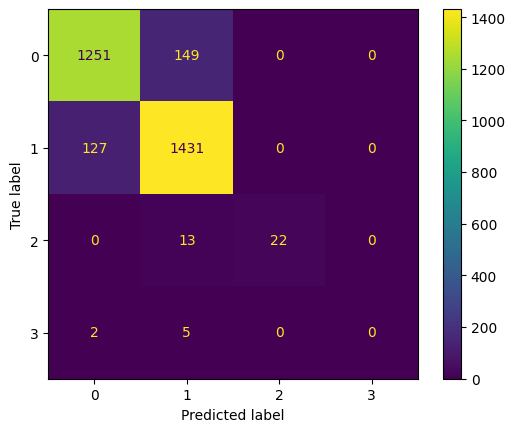

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions from the trainer
predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.savefig("confusion_matrix.png")

NoteBook 04 : explainability_visualization

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


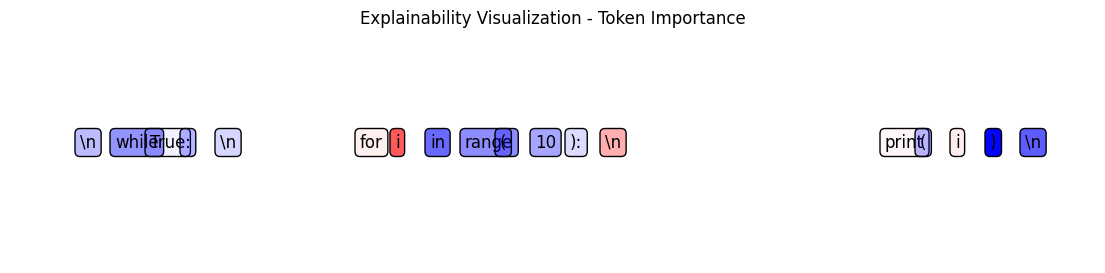

In [31]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from captum.attr import LayerIntegratedGradients

# ============================================
# LOAD MODEL
# ============================================

model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/codebert-base",
    num_labels=4
)

tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/codebert-base"
)

model.eval()

# ============================================
# SAMPLE CODE
# ============================================

code_sample = """
while True:
    for i in range(10):
        print(i)
"""

# ============================================
# TOKENIZE
# ============================================

inputs = tokenizer(
    code_sample,
    return_tensors="pt",
    truncation=True
)

input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

# ============================================
# FORWARD FUNCTION
# ============================================

def forward_func(input_ids, attention_mask):

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    return outputs.logits

# ============================================
# CAPTUM
# ============================================

lig = LayerIntegratedGradients(
    forward_func,
    model.roberta.embeddings
)

# Prediction
outputs = model(**inputs)

pred_class = torch.argmax(outputs.logits, dim=1).item()

# Baseline
baseline = torch.zeros_like(input_ids)

# Attribution
attributions, delta = lig.attribute(
    inputs=input_ids,
    baselines=baseline,
    additional_forward_args=(attention_mask,),
    target=pred_class,
    return_convergence_delta=True
)

# ============================================
# PROCESS ATTRIBUTIONS
# ============================================

scores = attributions.sum(dim=-1).squeeze(0)

tokens = tokenizer.convert_ids_to_tokens(
    input_ids.squeeze(0)
)

# Clean tokens
clean_tokens = []

for token in tokens:

    token = token.replace("Ġ", "")
    token = token.replace("Ċ", "\\n")
    token = token.replace("<s>", "")
    token = token.replace("</s>", "")

    clean_tokens.append(token)

# Normalize scores
scores = scores.detach().numpy()

max_score = max(abs(scores))

normalized_scores = scores / max_score

# ============================================
# CREATE HEATMAP VISUALIZATION
# ============================================

fig, ax = plt.subplots(figsize=(14, 3))

for i, (token, score) in enumerate(zip(clean_tokens, normalized_scores)):

    color_intensity = abs(score)

    if score > 0:
        color = (1, 0, 0, color_intensity)  # red
    else:
        color = (0, 0, 1, color_intensity)  # blue

    ax.text(
        i,
        0,
        token,
        fontsize=12,
        bbox=dict(
            facecolor=color,
            edgecolor='black',
            boxstyle='round,pad=0.3'
        )
    )

ax.set_xlim(-1, len(clean_tokens))
ax.set_ylim(-1, 1)

ax.axis('off')

plt.title("Explainability Visualization - Token Importance")

# SAVE IMAGE
plt.savefig("explainability_heatmap.png", bbox_inches='tight')

plt.show()